In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
tickers = ["AAPL", "AMZN", "JPM", "NVDA", "TSLA"]
data = yf.download(tickers, start="2023-01-01", end="2024-12-31")
close_prices = data['Close']
print(close_prices)

[*********************100%***********************]  5 of 5 completed

Ticker            AAPL        AMZN         JPM        NVDA        TSLA
Date                                                                  
2023-01-03  122.982704   85.820000  124.292595   14.283262  108.099998
2023-01-04  124.251183   85.139999  125.451660   14.716299  113.639999
2023-01-05  122.933548   83.120003  125.423843   14.233374  110.339996
2023-01-06  127.456779   86.080002  127.823883   14.826057  113.059998
2023-01-09  127.977890   87.360001  127.295692   15.593352  119.769997
...                ...         ...         ...         ...         ...
2024-12-23  253.649429  225.059998  231.216568  139.461700  430.600006
2024-12-24  256.560883  229.050003  235.018600  140.010895  462.279999
2024-12-26  257.375610  227.050003  235.823624  139.721313  454.130005
2024-12-27  253.967377  223.750000  233.912903  136.805664  431.660004
2024-12-30  250.598907  221.300003  232.118561  137.284958  417.410004

[501 rows x 5 columns]


In [3]:
ret = round((close_prices.iloc[-1] - close_prices.iloc[0]) / close_prices.iloc[0] * 100, 2)
print(ret)

Ticker
AAPL    103.77
AMZN    157.87
JPM      86.75
NVDA    861.16
TSLA    286.13
dtype: float64


In [5]:
daily_ret = close_prices.pct_change()

vol = daily_ret.std()
annual_vol = vol * (252 ** 0.5)

sharpe = (ret / 100) / annual_vol

print(daily_ret)
print(annual_vol)
print(sharpe)

Ticker          AAPL      AMZN       JPM      NVDA      TSLA
Date                                                        
2023-01-03       NaN       NaN       NaN       NaN       NaN
2023-01-04  0.010314 -0.007924  0.009325  0.030318  0.051249
2023-01-05 -0.010605 -0.023726 -0.000222 -0.032816 -0.029039
2023-01-06  0.036794  0.035611  0.019135  0.041640  0.024651
2023-01-09  0.004089  0.014870 -0.004132  0.051753  0.059349
...              ...       ...       ...       ...       ...
2024-12-23  0.003065  0.000622  0.003325  0.036897  0.022657
2024-12-24  0.011478  0.017729  0.016444  0.003938  0.073572
2024-12-26  0.003176 -0.008732  0.003425 -0.002068 -0.017630
2024-12-27 -0.013242 -0.014534 -0.008102 -0.020868 -0.049479
2024-12-30 -0.013263 -0.010950 -0.007671  0.003503 -0.033012

[501 rows x 5 columns]
Ticker
AAPL    0.213671
AMZN    0.306426
JPM     0.221876
NVDA    0.504982
TSLA    0.583093
dtype: float64
Ticker
AAPL     4.856531
AMZN     5.151978
JPM      3.909835
NVDA    17.0532

In [11]:
import numpy as np

num_portfolios = 10000
results = []

for i in range(num_portfolios):
    weights = np.random.random(5)
    weights = weights / weights.sum()
    

    port_return = np.dot(weights, ret / 100)
    port_vol = np.sqrt(np.dot(weights, (daily_ret.std() * np.sqrt(252)) ** 2))
    port_sharpe = port_return / port_vol

    results.append([port_return, port_vol, port_sharpe, weights])
print("Done")

Done


In [13]:
results_df = pd.DataFrame(results, columns=['Return', 'Volatility', 'Sharpe', 'Weights'])
best = results_df.loc[results_df['Sharpe'].idxmax()]
print(best)

tickers = ["AAPL", "AMZN", "JPM", "NVDA", "TSLA"]
best_weights = best['Weights']

for ticker, weight in zip(tickers, best_weights):
    print(f"{ticker}: {round(weight * 100, 2)}%")

Return                                                 7.241879
Volatility                                             0.497279
Sharpe                                                14.563009
Weights       [0.029459649479188655, 0.0064425098075890416, ...
Name: 6153, dtype: object
AAPL: 2.95%
AMZN: 0.64%
JPM: 5.24%
NVDA: 79.08%
TSLA: 12.09%


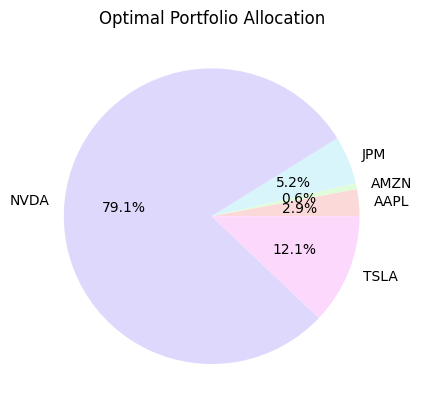

In [17]:
import matplotlib.pyplot as plt

plt.pie(best_weights, labels=tickers, colors=['#fcd9d9', '#e0fcd9', '#d9f5fc', '#ded9fc', '#fcd9fc'], autopct='%1.1f%%')
plt.title('Optimal Portfolio Allocation')
plt.show()


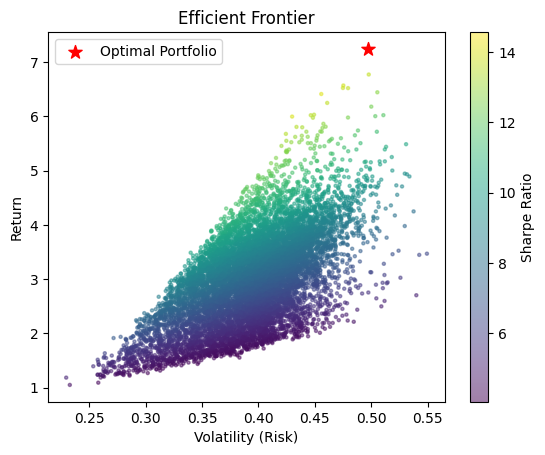

In [18]:
plt.scatter(results_df['Volatility'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.5, s=5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(best['Volatility'], best['Return'], color='red', s=100, marker='*', label='Optimal Portfolio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.legend()
plt.show()